In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNNBaseline(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 4):
        """
        Default is set for brain tumor:
        - in_channels = 3 (RGB images)
        - num_classes = 4 (glioma, meningioma, notumor, pituitary)
        """
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)

        # Make it independent of input size by pooling down to 2×2
        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        # 64 channels * 2 * 2 = 256 (same as your old version)
        self.linear1 = nn.Linear(256, 128)
        self.linear2 = nn.Linear(128, num_classes)

        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))
        x = self.pool(x)                      # (B, 64, 2, 2)
        x = x.view(x.size(0), -1)             # (B, 256)

        x = self.act(self.linear1(x))
        x = F.log_softmax(self.linear2(x), dim=-1)
        return x

In [7]:
from matplotlib import pyplot as plt
import numpy as np


def train(train_loader, model, optimizer, epochs):
    device = next(model.parameters()).device
    model.train()
    losses = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        for step, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            if step % 50 == 0 and step > 0:
                print(
                    f"[Step {step}] Mean last 50 losses: {np.mean(losses[-50:]):.4f}")

    # plot loss curve
    plt.plot(losses)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.show()


@torch.no_grad()
def evaluate(eval_loader, model):
    device = next(model.parameters()).device
    model.eval()
    accuracies = []

    for inputs, labels in eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        batch_acc = (preds == labels).float().mean().item()
        accuracies.append(batch_acc)

    accuracy = np.mean(accuracies)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    return accuracy


    return accuracy

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5712
Number of testing images: 1311

Epoch 1/10
[Step 50] Mean last 50 losses: 1.2530
[Step 100] Mean last 50 losses: 1.0626
[Step 150] Mean last 50 losses: 1.0261

Epoch 2/10
[Step 50] Mean last 50 losses: 0.9776
[Step 100] Mean last 50 losses: 0.9542
[Step 150] Mean last 50 losses: 0.9122

Epoch 3/10
[Step 50] Mean last 50 losses: 0.8390
[Step 100] Mean last 50 losses: 0.7829
[Step 150] Mean last 50 losses: 0.7481

Epoch 4/10
[Step 50] Mean last 50 losses: 0.6589
[Step 100] Mean last 50 losses: 0.6097
[Step 150] Mean last 50 losses: 0.5986

Epoch 5/10
[Step 50] Mean last 50 losses: 0.5016
[Step 100] Mean last 50 losses: 0.4709
[Step 150] Mean last 50 losses: 0.4430

Epoch 6/10
[Step 50] Mean last 50 losses: 0.3678
[Step 100] Mean last 50 losses: 0.3886
[Step 150] Mean last 50 losses: 0.3701

Epoch 7/10
[Step 50] Mean last 50 losses: 0.3175
[Step 100] Mean last 50 losses: 0.3202
[Step 150] Mean last 5

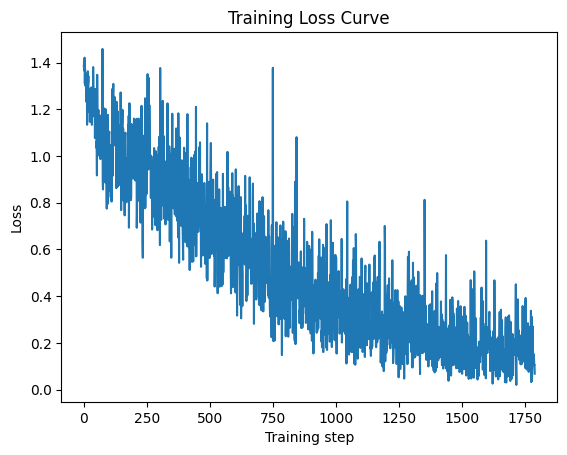

Accuracy: 91.84%


0.9184205343083638

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.optim as optim

transform = transforms.Compose([
    transforms.Resize((224, 224)),          
    # convert to tensor (C,H,W), values in [0,1]
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),                # for 3-channel RGB
        std=(0.5, 0.5, 0.5)
    )
])

train_data = datasets.ImageFolder(
    root="/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Training", transform=transform)
test_data = datasets.ImageFolder(
    root="/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Testing",  transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# should be ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Classes:", train_data.classes)
print("Number of training images:", len(train_data))
print("Number of testing images:", len(test_data))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNBaseline(
    in_channels=3,                     # RGB images
    num_classes=len(train_data.classes)  # usually 4
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train & eval with your existing functions
train(train_loader, model, optimizer, epochs=10)
evaluate(test_loader, model)